Attempting to load data from: ../../data/processed/11_international_movements.csv
Data loaded successfully.

First 5 rows of the data:
   year  foreign_to_brazilian_movements  brazilian_to_foreign_movements
0  2015                              68                              63
1  2016                             100                              88
2  2017                             138                             151
3  2018                             164                             191
4  2019                             162                             208

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   year                            10 non-null     int64
 1   foreign_to_brazilian_movements  10 non-null     int64
 2   brazilian_to_foreign_movements  10 non-null     int64
dtypes: int64(3)
memory u

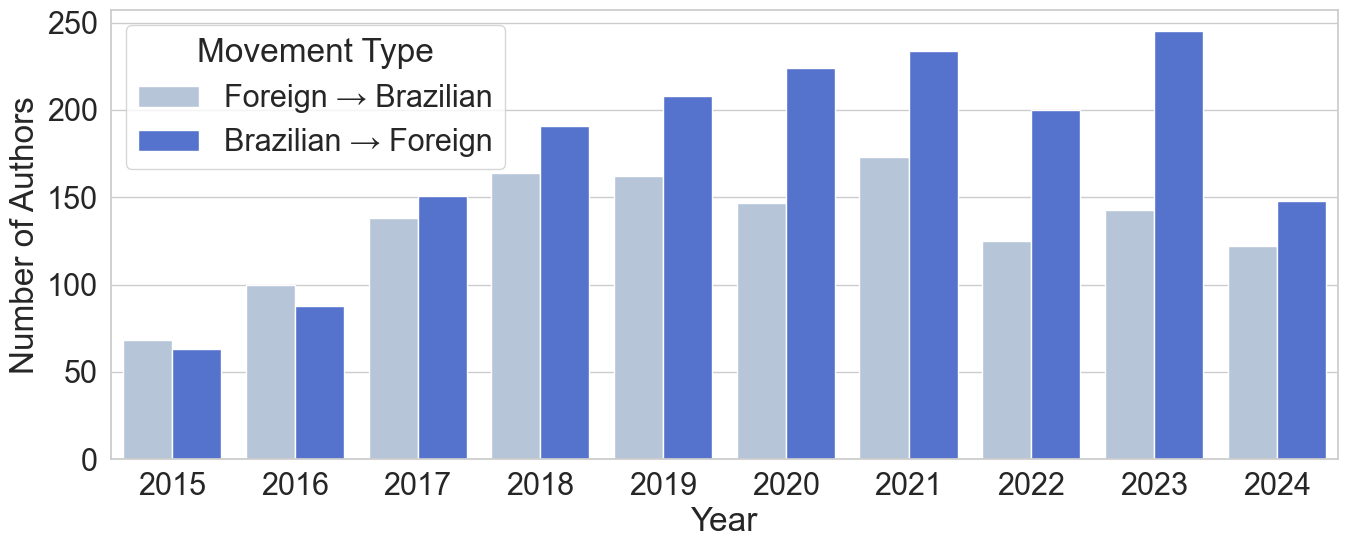

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuration ---
# Define the path to the yearly movements data file
# Ensure this path is correct relative to where your Jupyter Notebook is run
YEARLY_DATA_FILE = "../../data/processed/11_international_movements.csv"

# --- Load Data ---
print(f"Attempting to load data from: {YEARLY_DATA_FILE}")
if not os.path.exists(YEARLY_DATA_FILE):
    print(f"Error: The file '{YEARLY_DATA_FILE}' was not found.")
    print(
        "Please ensure the previous script has been run and the file path is correct."
    )
    # Create an empty DataFrame to prevent errors if the file doesn't exist
    yearly_df = pd.DataFrame(
        columns=[
            "year",
            "foreign_to_brazilian_movements",
            "brazilian_to_foreign_movements",
        ]
    )
else:
    try:
        yearly_df = pd.read_csv(YEARLY_DATA_FILE)
        print("Data loaded successfully.")
        print("\nFirst 5 rows of the data:")
        print(yearly_df.head())
        print("\nData Info:")
        yearly_df.info()
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")
        yearly_df = pd.DataFrame(
            columns=[
                "year",
                "foreign_to_brazilian_movements",
                "brazilian_to_foreign_movements",
            ]
        )

# --- Data Preprocessing (if necessary) ---
# Ensure 'year' column is integer and sorted
if "year" in yearly_df.columns:
    yearly_df["year"] = yearly_df["year"].astype(int)
    yearly_df = yearly_df.sort_values(by="year").reset_index(drop=True)

# --- Visualization ---

if not yearly_df.empty:
    print("\nGenerating visualizations...")

    # Set a nice style for seaborn plots
    sns.set_theme(style="whitegrid", font_scale=2)

    # Bar Plot for comparison
    plt.figure(figsize=(14, 6))
    yearly_melted_df = yearly_df.melt(
        "year", var_name="Movement Type", value_name="Number of Authors"
    )
    yearly_melted_df["Movement Type"] = yearly_melted_df["Movement Type"].replace(
        {
            "foreign_to_brazilian_movements": "Foreign → Brazilian",
            "brazilian_to_foreign_movements": "Brazilian → Foreign",
        }
    )
    sns.barplot(
        x="year",
        y="Number of Authors",
        hue="Movement Type",
        data=yearly_melted_df,
        palette={"Foreign → Brazilian": "lightsteelblue", "Brazilian → Foreign": "royalblue"},
    )
    plt.xlabel("Year")
    plt.ylabel("Number of Authors")
    plt.legend(title="Movement Type")
    plt.tight_layout()

    plt.savefig(
        fname="../../results/figures/international_movements.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()

else:
    print(
        "\nNo data available to generate visualizations. Please check the data file and its path."
    )